# 🎬 Movie Dataset Analysis using Python

This project explores movie data to identify trends, relationships, and business insights using Python.

In [5]:
import kagglehub
import shutil
import os

# Download dataset
path = kagglehub.dataset_download(
    "mjshubham21/movie-dataset-for-analytics-and-visualization"
)

# Create folder in Colab
os.makedirs("/content/movie_dataset", exist_ok=True)

# Copy all files from cache to /content
for file in os.listdir(path):
    shutil.copy(os.path.join(path, file), "/content/movie_dataset")

print("Done!")

Using Colab cache for faster access to the 'movie-dataset-for-analytics-and-visualization' dataset.
Done!


## 📚 Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Load Dataset

In [7]:
import pandas as pd

df = pd.read_csv("/content/movie_dataset/movies_dataset.csv")

df.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-2003,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-1988,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-1998,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS


## 🔍 Initial Data Exploration

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MovieID               999999 non-null  int64  
 1   Title                 999999 non-null  object 
 2   Genre                 999999 non-null  object 
 3   ReleaseYear           999999 non-null  int64  
 4   ReleaseDate           999999 non-null  object 
 5   Country               999999 non-null  object 
 6   BudgetUSD             999999 non-null  float64
 7   US_BoxOfficeUSD       999999 non-null  float64
 8   Global_BoxOfficeUSD   999999 non-null  float64
 9   Opening_Day_SalesUSD  999999 non-null  float64
 10  One_Week_SalesUSD     999999 non-null  float64
 11  IMDbRating            999999 non-null  float64
 12  RottenTomatoesScore   999999 non-null  int64  
 13  NumVotesIMDb          999999 non-null  int64  
 14  NumVotesRT            999999 non-null  int64  
 15  

In [9]:
df.tail()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
999994,999995,He anyone,Action,2011,14-09-2011,China,648176.38,1075869.51,2624306.41,170212.67,614079.92,4.8,58,12664,586,Nathan Bolton,Stephanie Moore
999995,999996,Single yourself sister collection,Horror,1982,27-08-1982,USA,657167.15,1046949.86,2164587.12,119899.27,564950.72,7.3,83,622,2327,David Lee,Tracy Klein
999996,999997,Old economic,Documentary,1993,12-02-1993,USA,29914685.15,30619499.73,57774787.73,6331667.63,18136941.88,4.1,32,100,1394,Jeremy Davis,Lynn Pierce
999997,999998,My itself and leave,Horror,2013,11-11-2013,India,1382498.55,3168114.87,5567631.38,438945.44,1703606.02,4.3,23,2337,105,Melanie Olson,Melissa Mcgee
999998,999999,Congress federal policy,Drama,1995,09-08-1995,USA,7655641.81,18626549.48,34908325.31,4342391.46,10764341.98,6.6,60,24528,872,Albert Phillips,Samantha Sanders


In [10]:
# find how many row and column
df.shape

(999999, 17)

In [11]:
# find data type of each column
df.dtypes

,0
MovieID,int64
Title,object
Genre,object
ReleaseYear,int64
ReleaseDate,object
Country,object
BudgetUSD,float64
US_BoxOfficeUSD,float64
Global_BoxOfficeUSD,float64
Opening_Day_SalesUSD,float64


In [12]:
df.describe()

,MovieID,ReleaseYear,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
count,999999.000000,999999.000000,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,999999.000000,999999.000000,999999.000000,999999.000000
mean,500000.000000,1998.001220,9.802824e+06,1.496163e+07,2.720625e+07,2.992745e+06,7.483442e+06,6.494788,64.776426,9137.184011,2031.880340
std,288674.990255,19.260863,2.249421e+07,3.879403e+07,6.954294e+07,8.132438e+06,1.955337e+07,1.485606,17.592474,24922.362780,8433.380602
min,1.000000,1950.000000,1.000000e+05,4.002547e+04,1.000000e+05,4.050470e+03,1.650742e+04,1.000000,0.000000,100.000000,50.000000
25%,250000.500000,1984.000000,1.190511e+06,1.489805e+06,2.762370e+06,2.790262e+05,7.383145e+05,5.500000,53.000000,1083.000000,119.000000
50%,500000.000000,2001.000000,3.265790e+06,4.388876e+06,8.090223e+06,8.387221e+05,2.179436e+06,6.500000,65.000000,2983.000000,405.000000
75%,749999.500000,2014.000000,9.002791e+06,1.287606e+07,2.355245e+07,2.510360e+06,6.415143e+06,7.500000,77.000000,8192.000000,1360.000000
max,999999.000000,2025.000000,3.000000e+08,1.018198e+09,1.499497e+09,2.957511e+08,5.795551e+08,10.000000,100.000000,1000000.000000,500000.000000


## 🧹 Data Cleaning

In [13]:
# Check whether the dataset contains any null values.
df.isna().sum()

,0
MovieID,0
Title,0
Genre,0
ReleaseYear,0
ReleaseDate,0
Country,0
BudgetUSD,0
US_BoxOfficeUSD,0
Global_BoxOfficeUSD,0
Opening_Day_SalesUSD,0


In [14]:
df.isna().sum().sum()

np.int64(0)

In [15]:
# Check whether any column contains duplicate values.
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
999994,False
999995,False
999996,False
999997,False


In [16]:
df.duplicated().sum()

np.int64(0)

## 📊 Univariate Analysis

In [17]:
df.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'ReleaseDate', 'Country',
       'BudgetUSD', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD',
       'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
       'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT', 'Director',
       'LeadActor'],
      dtype='object')

In [18]:
numeric_cols = ['BudgetUSD', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD',
       'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
       'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT']

In [19]:
for cols in numeric_cols:
    print(cols)

BudgetUSD
US_BoxOfficeUSD
Global_BoxOfficeUSD
Opening_Day_SalesUSD
One_Week_SalesUSD
IMDbRating
RottenTomatoesScore
NumVotesIMDb
NumVotesRT


In [20]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# histograms using seaborn

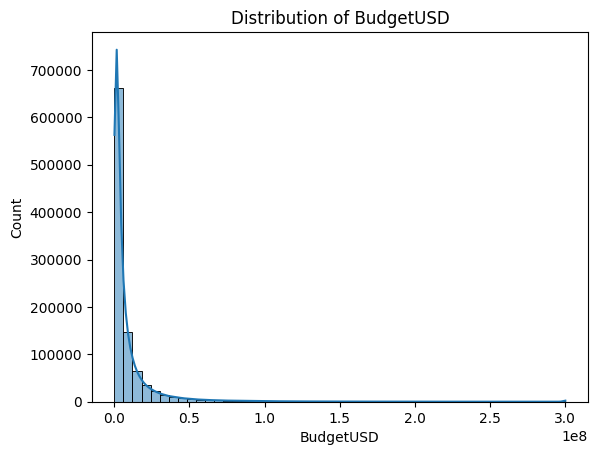

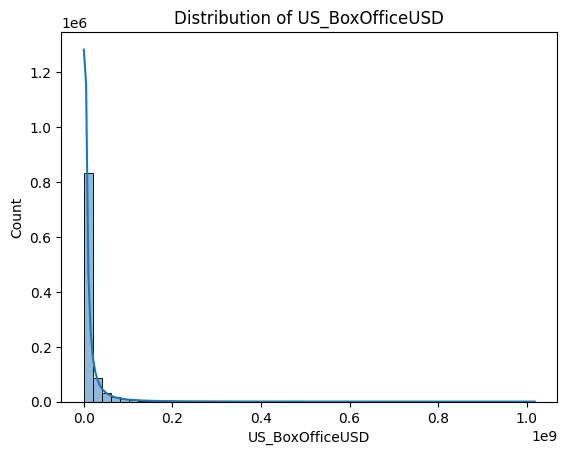

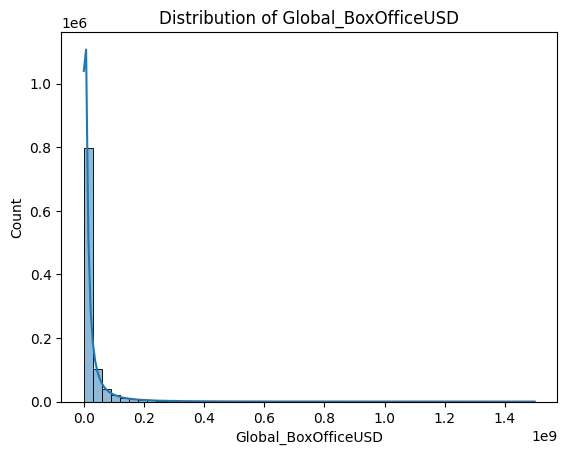

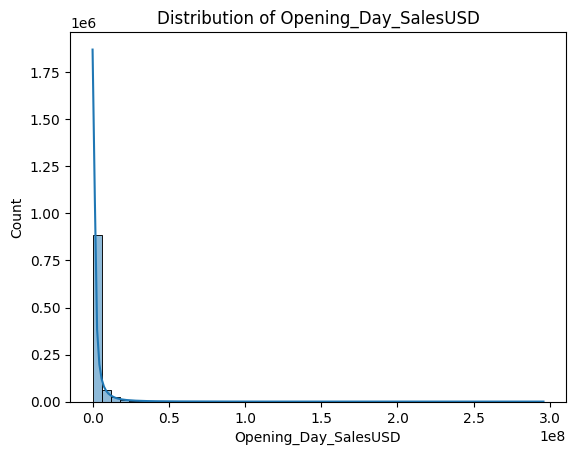

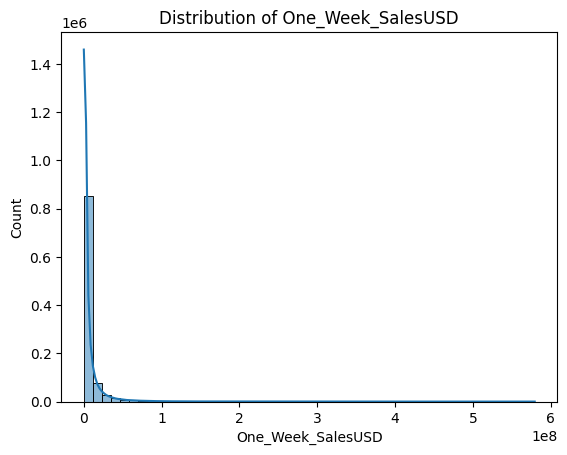

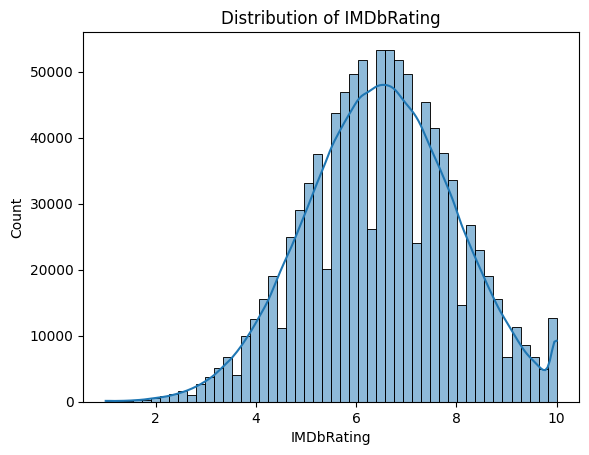

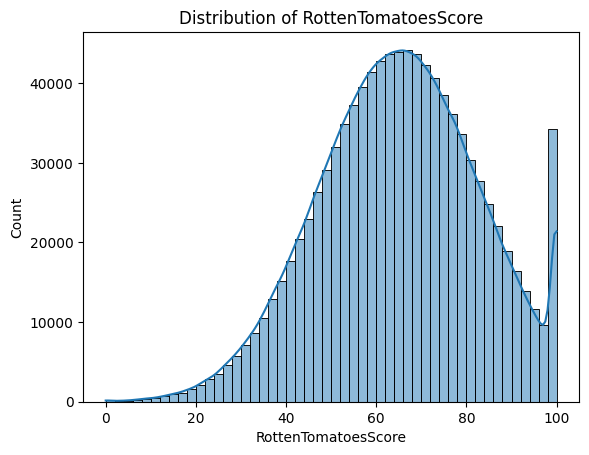

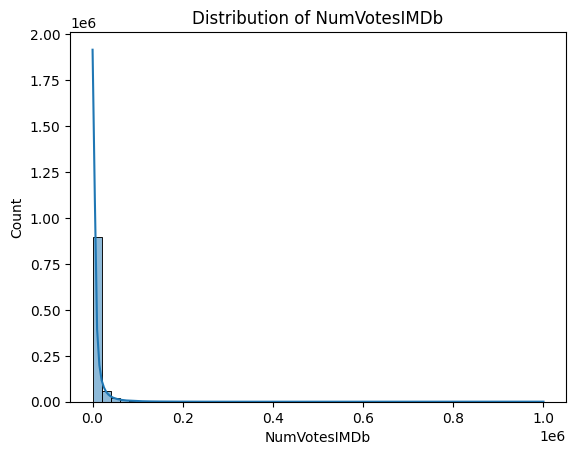

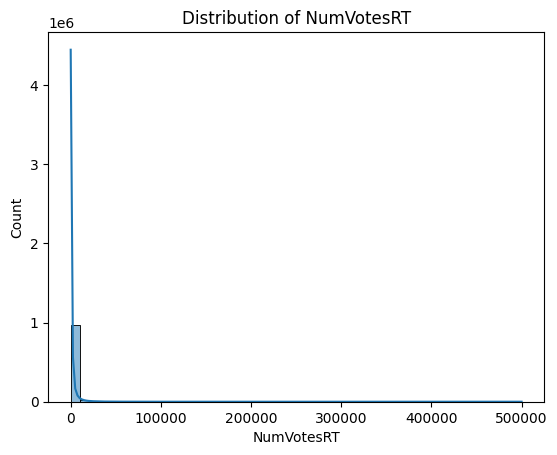

In [21]:
# bins controls the number of grouping intervals for the histogram bars,
# and kde adds a smooth probability curve over the bars.
for cols in numeric_cols:
    sns.histplot(df[cols], bins=50, kde=True)
    plt.title(f"Distribution of {cols}")
    plt.show()


In [22]:
df.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'ReleaseDate', 'Country',
       'BudgetUSD', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD',
       'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
       'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT', 'Director',
       'LeadActor'],
      dtype='object')

In [23]:
categorial_cols = ['Genre','Country','Director',
       'LeadActor']

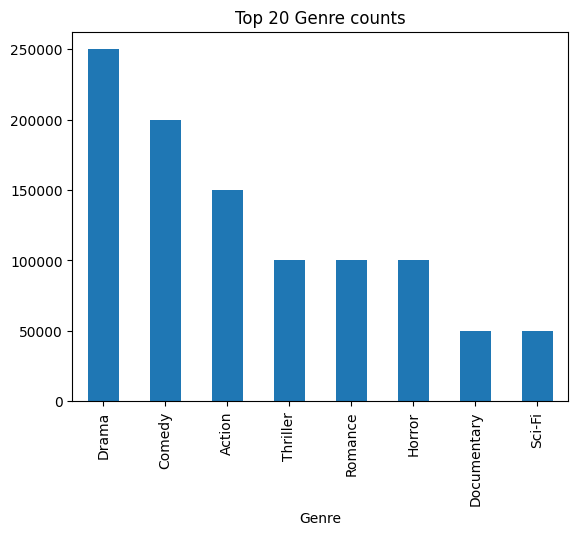

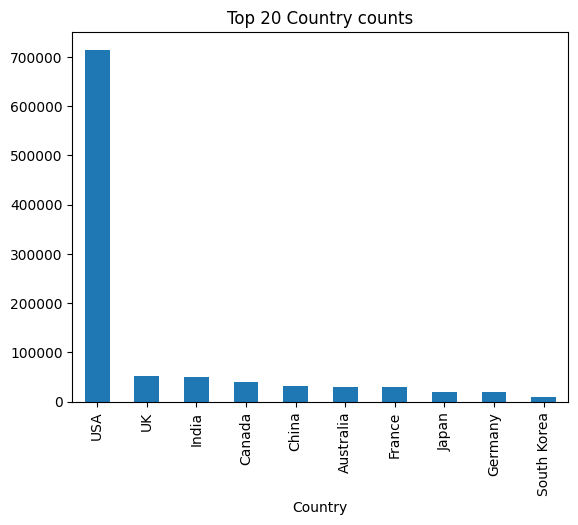

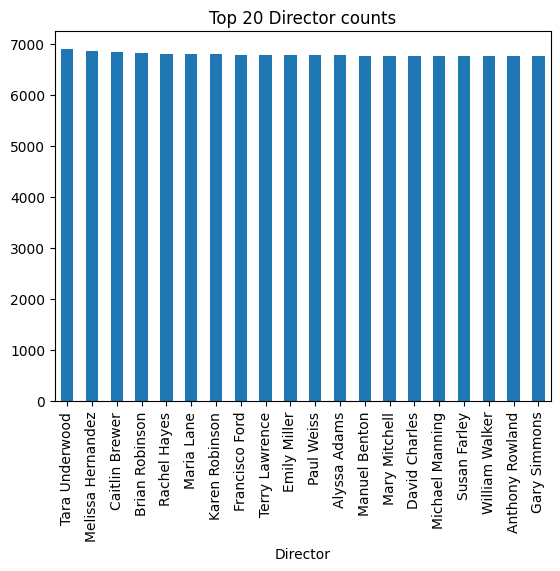

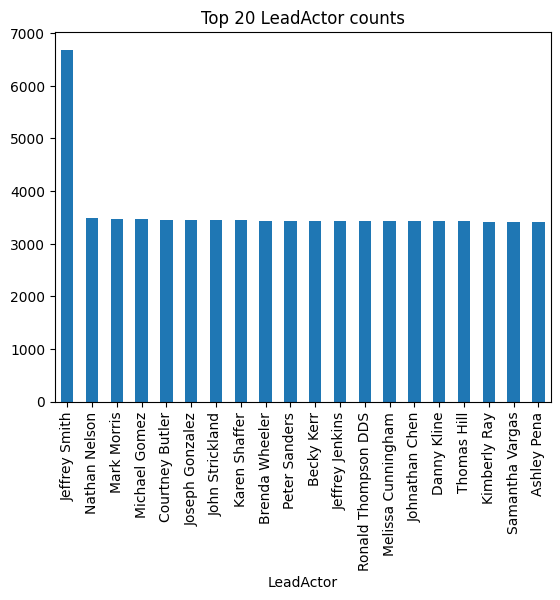

In [24]:
for col in categorial_cols:
    df[col].value_counts().head(20).plot(kind='bar')
    plt.title(f"Top 20 {col} counts")
    plt.show()

In [25]:
df.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'ReleaseDate', 'Country',
       'BudgetUSD', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD',
       'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
       'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT', 'Director',
       'LeadActor'],
      dtype='object')

In [ ]:
# alpha controls the transparency (opacity) of the points.

# alpha = 1 → Completely visible (default)
# alpha = 0.5 → 50% transparent
# alpha = 0.3 → 30% visible (70% transparent)
# alpha = 0 → Completely invisible



## 💰 Budget vs Box Office Revenue

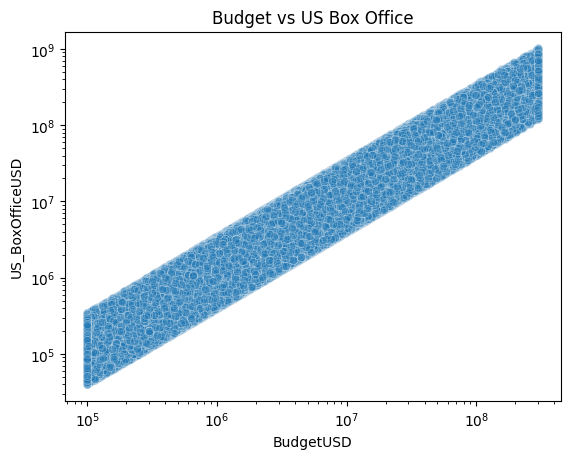

In [30]:
sns.scatterplot(x='BudgetUSD', y='US_BoxOfficeUSD', data=df , alpha=0.3)
plt.title('Budget vs US Box Office')
plt.xscale('log')
plt.yscale('log')
plt.show()


## IMDB VS RottenTomates Rating

In [31]:
df.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'ReleaseDate', 'Country',
       'BudgetUSD', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD',
       'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
       'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT', 'Director',
       'LeadActor'],
      dtype='object')

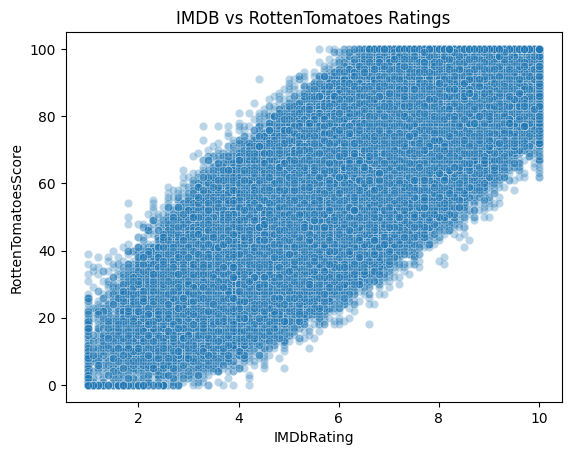

In [35]:
sns.scatterplot(x='IMDbRating', y='RottenTomatoesScore', data=df , alpha=0.3)
plt.title('IMDB vs RottenTomatoes Ratings')
# plt.xscale('log')
# plt.yscale('log')
plt.show()

## 🎭 Genre-wise Analysis

In [36]:
df.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'ReleaseDate', 'Country',
       'BudgetUSD', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD',
       'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
       'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT', 'Director',
       'LeadActor'],
      dtype='object')

In [39]:
genre_year_stats = df.groupby(['Genre', 'ReleaseYear']).agg({
    'BudgetUSD': 'mean',
    'RottenTomatoesScore' : 'mean',
    'Global_BoxOfficeUSD': 'mean',
    'IMDbRating': 'mean'
}).reset_index()

In [41]:
genre_year_stats

,Genre,ReleaseYear,BudgetUSD,RottenTomatoesScore,Global_BoxOfficeUSD,IMDbRating
0,Action,1950,1.011213e+07,63.564841,2.897931e+07,6.361671
1,Action,1951,1.027247e+07,65.671233,2.896091e+07,6.546575
2,Action,1952,9.683596e+06,64.175589,2.789712e+07,6.487152
3,Action,1953,9.471222e+06,63.466801,2.762857e+07,6.387726
4,Action,1954,1.054447e+07,64.107955,3.244328e+07,6.511553
...,...,...,...,...,...,...
603,Thriller,2021,1.012603e+07,64.689465,2.859975e+07,6.477995
604,Thriller,2022,9.452524e+06,64.122777,2.670292e+07,6.466554
605,Thriller,2023,9.877671e+06,65.149914,2.694591e+07,6.527363
606,Thriller,2024,9.764218e+06,64.358491,2.576942e+07,6.490901


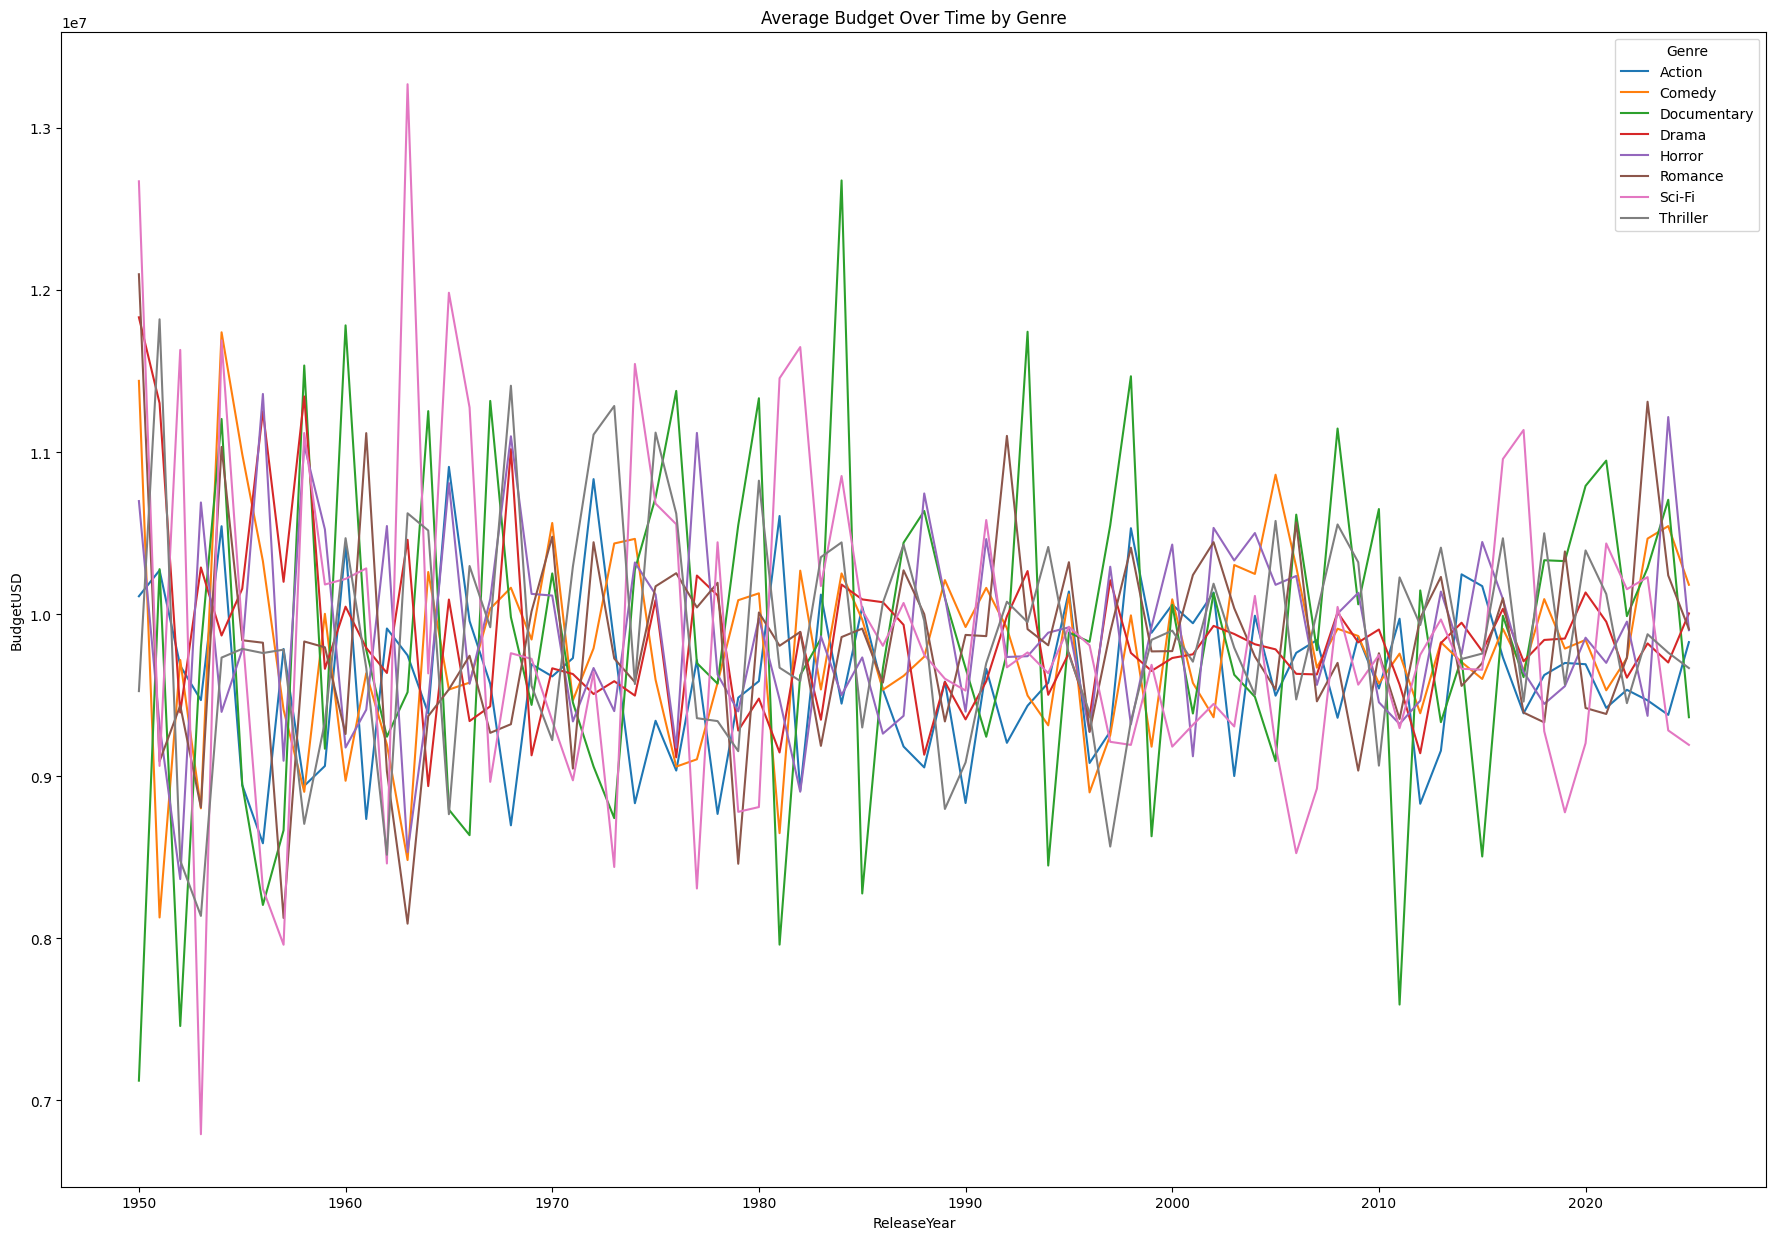

In [55]:
plt.figure(figsize=(22,15))
sns.lineplot(x='ReleaseYear', y='BudgetUSD', hue='Genre', data=genre_year_stats)
plt.title('Average Budget Over Time by Genre')

plt.show()

In [56]:
df.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'ReleaseDate', 'Country',
       'BudgetUSD', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD',
       'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
       'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT', 'Director',
       'LeadActor'],
      dtype='object')

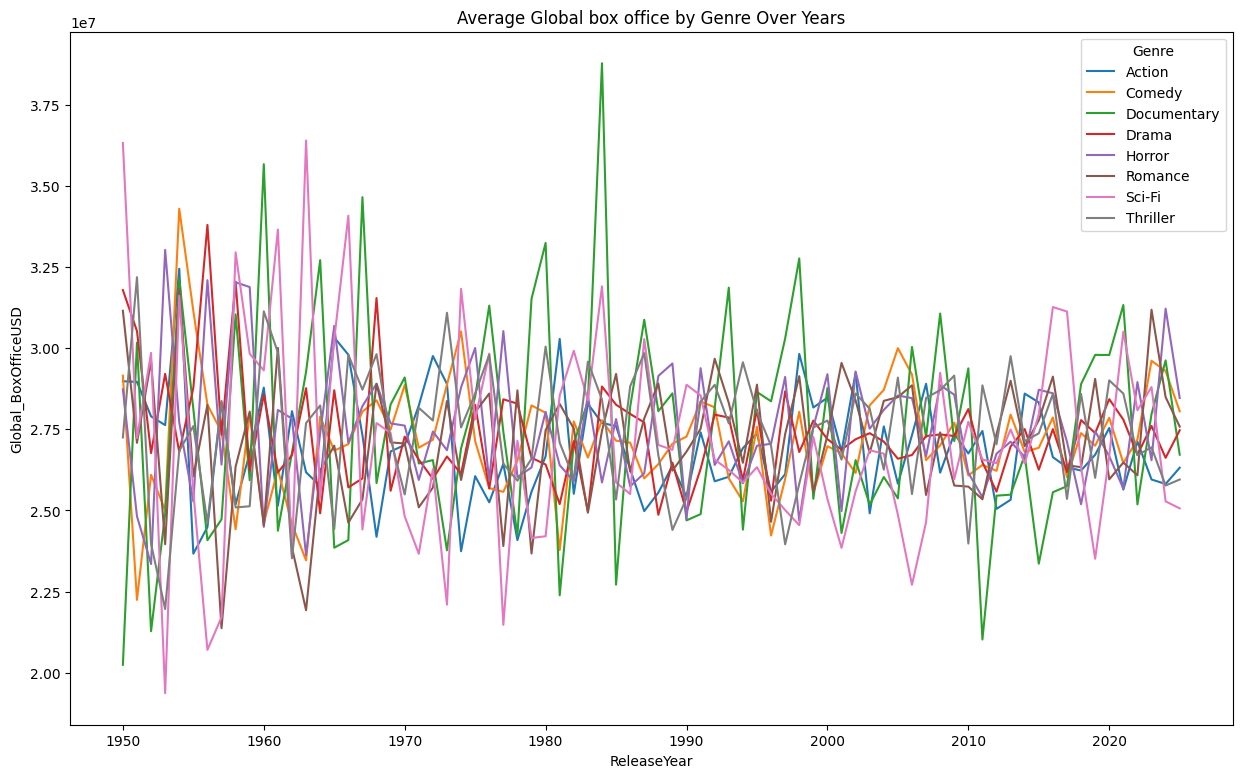

In [57]:
plt.figure(figsize=(15,9))
sns.lineplot(x='ReleaseYear', y='Global_BoxOfficeUSD', hue='Genre', data=genre_year_stats)
plt.title('Average Global box office by Genre Over Years')
plt.show()

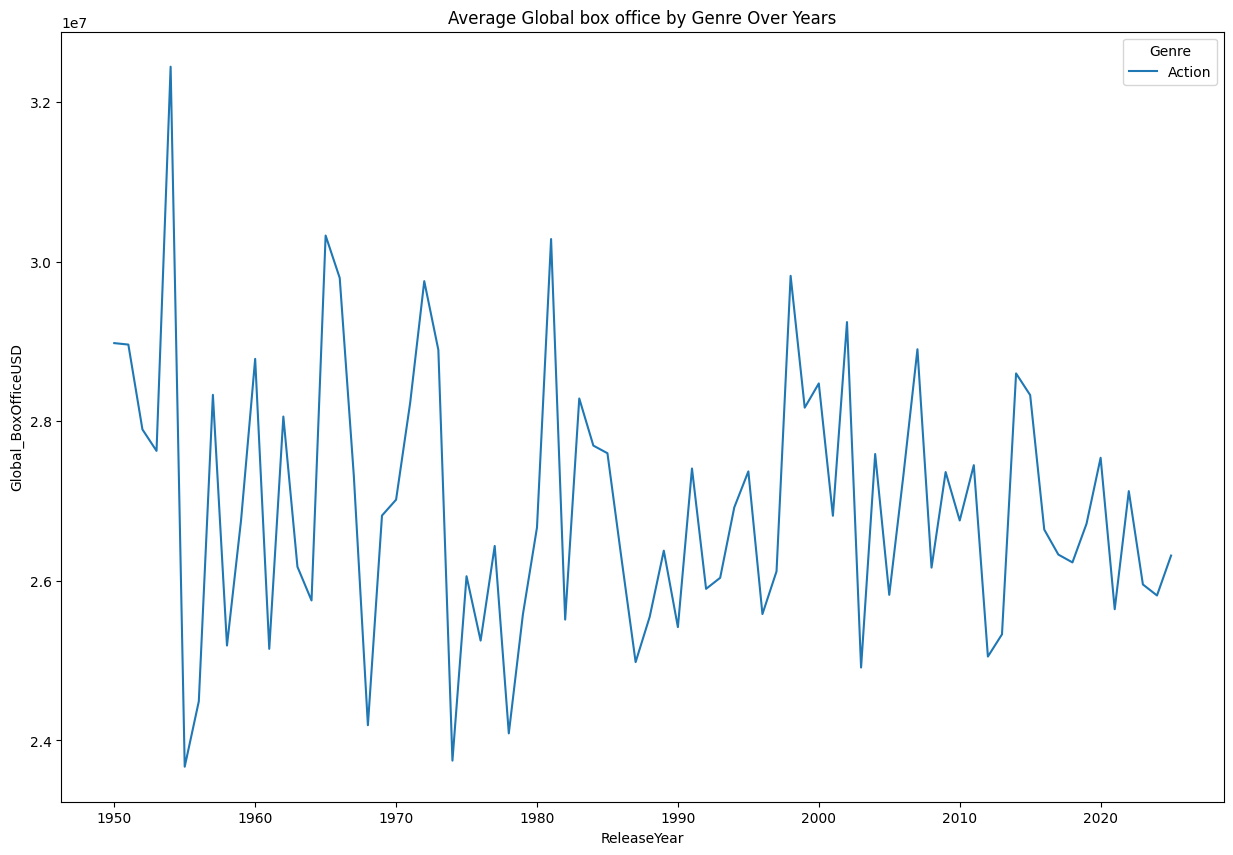

In [59]:
plt.figure(figsize=(15,10))
sns.lineplot(x='ReleaseYear', y='Global_BoxOfficeUSD', hue='Genre', data=genre_year_stats.query('Genre == "Action"'))
plt.title('Average Global box office by Genre Over Years')
plt.show()

## ⭐ Top Actors by Average IMDb Rating

In [63]:
top_actors = df.groupby("LeadActor")["IMDbRating"].mean().sort_values(ascending=False).head(10)


In [64]:
top_actors

,IMDbRating
LeadActor,
Meghan Mcintosh,6.566255
Meghan Johnson,6.556890
Carla Dougherty,6.554450
Jeffrey Haley,6.553223
Jennifer Cook,6.551508
Brandon Davidson,6.551028
Krystal Cross,6.547780
Morgan King,6.546569
Anthony Cross,6.546377


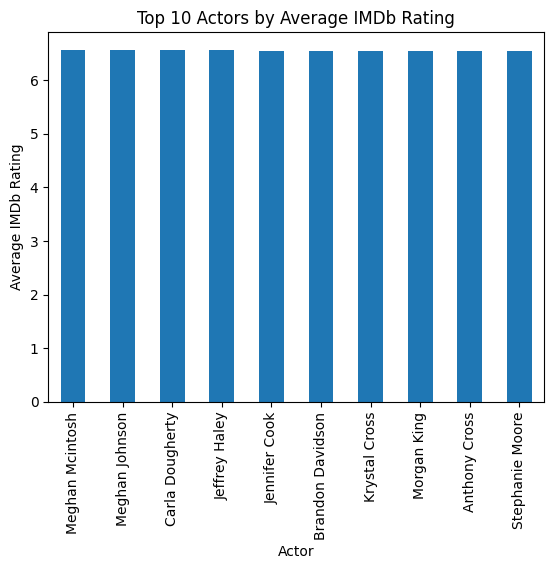

In [65]:
top_actors.plot(kind="bar")
plt.title("Top 10 Actors by Average IMDb Rating")
plt.xlabel("Actor")
plt.ylabel("Average IMDb Rating")
plt.show()

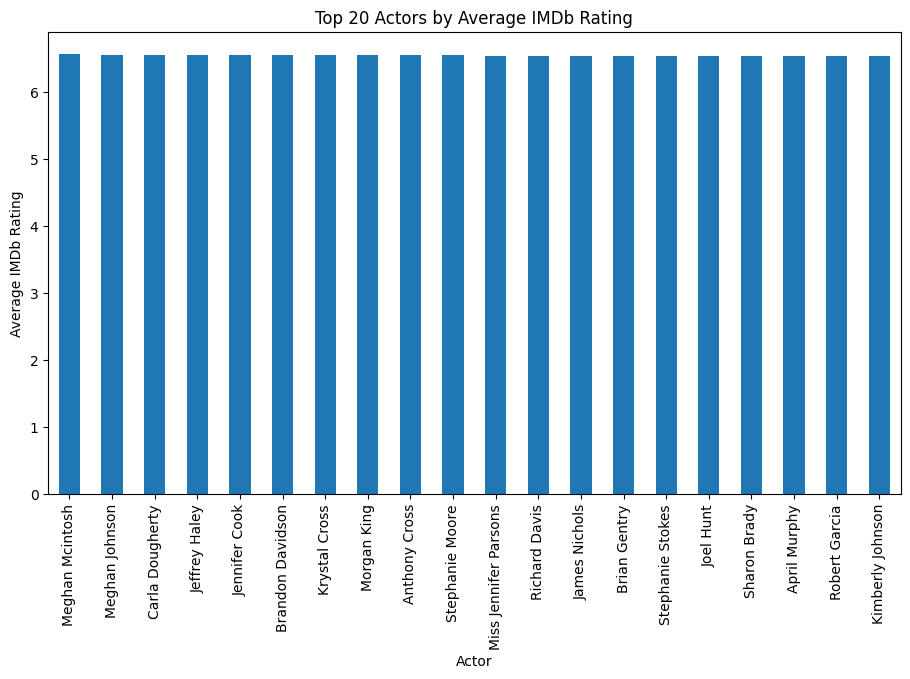

In [88]:
plt.figure(figsize=(11,6))
top_actors.head(20).plot(kind="bar")
plt.title("Top 20 Actors by Average IMDb Rating")
plt.xlabel("Actor")
plt.ylabel("Average IMDb Rating")
plt.show()

## 💡 Key Insights

- Movies with larger budgets generally earned higher revenue.
- Drama and Action were among the most common genres.
- Productive actors consistently achieved higher average IMDb ratings.
- Ratings and revenue did not always have a strong positive relationship.
